# SHAP Analysis & Lift Curve

Two business-facing analyses on the tuned XGBoost model:
- **SHAP**: what drives each prediction — globally and at the individual customer level
- **Lift curve**: how much better than random is the model at targeting converters

## 1. Setup & Load Model

In [ ]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()   # project root — all paths resolve from here
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from src.data import load_config, load_raw, clean, split
from src.features import build_feature_matrix
from src.model import load_model

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)
shap.initjs()

cfg       = load_config(ROOT / "config.yaml")
TARGET    = cfg["data"]["target_col"]
DROP_COLS = ["id", TARGET]

# Load data
df = clean(load_raw(ROOT / cfg["paths"]["raw_dir"]))
_, test_df = split(
    df,
    test_size=cfg["data"]["test_size"],
    random_state=cfg["split"]["random_state"],
)

# Stateless feature transforms
test_eng = build_feature_matrix(test_df)
X_test   = test_eng.drop(columns=DROP_COLS)
y_test   = test_eng[TARGET]

# Load saved model artifact from root models/ — no retraining
artifact  = load_model(ROOT / cfg["paths"]["model_file"])
pipeline  = artifact["pipeline"]
threshold = artifact["threshold"]

probs = pipeline.predict_proba(X_test)[:, 1]
print(f"Model loaded from: {ROOT / cfg['paths']['model_file']}")
print(f"Threshold: {threshold:.4f} | Test samples: {len(X_test):,}")

## 2. SHAP Values

In [2]:
# Transform test data through the pipeline's encoders to get the input
# the XGBoost model actually sees — required for correct SHAP values
X_test_transformed = pipeline[:-1].transform(X_test)

# Extract XGBoost model from pipeline
xgb_model = pipeline.named_steps["model"]
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Newer SHAP returns [neg_class, pos_class] for binary classifiers
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# ColumnTransformer is the last preprocessor and knows its output column order
# (FrequencyEncoder lacks get_feature_names_out, so we skip the full Pipeline call)
feature_names = (
    pipeline.named_steps["target_encoder"].get_feature_names_out().tolist()
)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (76222, 16)


## 3. Global Feature Importance (mean |SHAP|)

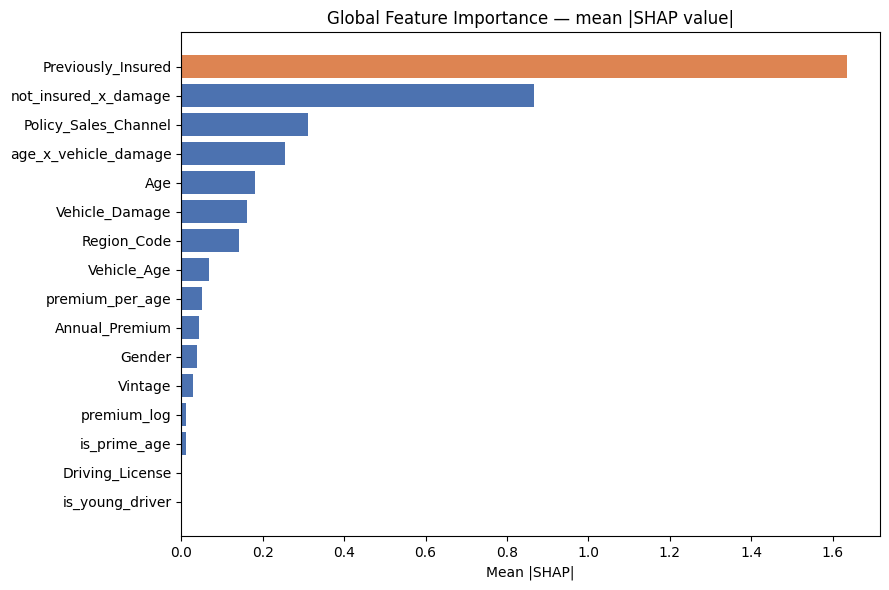

In [3]:
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_names,
).sort_values()

plt.figure(figsize=(9, 6))
colors = ["#DD8452" if v == mean_shap.max() else "#4C72B0" for v in mean_shap.values]
plt.barh(mean_shap.index, mean_shap.values, color=colors)
plt.title("Global Feature Importance — mean |SHAP value|")
plt.xlabel("Mean |SHAP|")
plt.tight_layout()

## 4. SHAP Beeswarm Plot

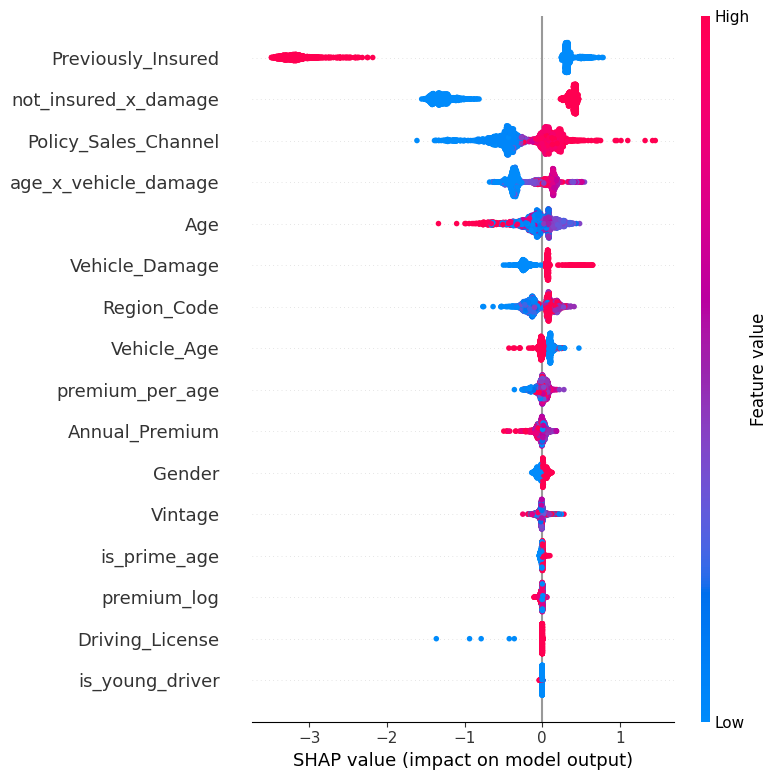

In [4]:
sample_idx = np.random.RandomState(42).choice(len(X_test_transformed), size=2000, replace=False)

if isinstance(X_test_transformed, np.ndarray):
    X_sample = pd.DataFrame(X_test_transformed[sample_idx], columns=feature_names)
else:
    X_sample = X_test_transformed.iloc[sample_idx]

sv_sample = shap_values[sample_idx]
shap.summary_plot(sv_sample, X_sample, plot_type="dot", show=True)

## 5. Individual Prediction Explanation


── High-probability converter (prob=0.853) ──


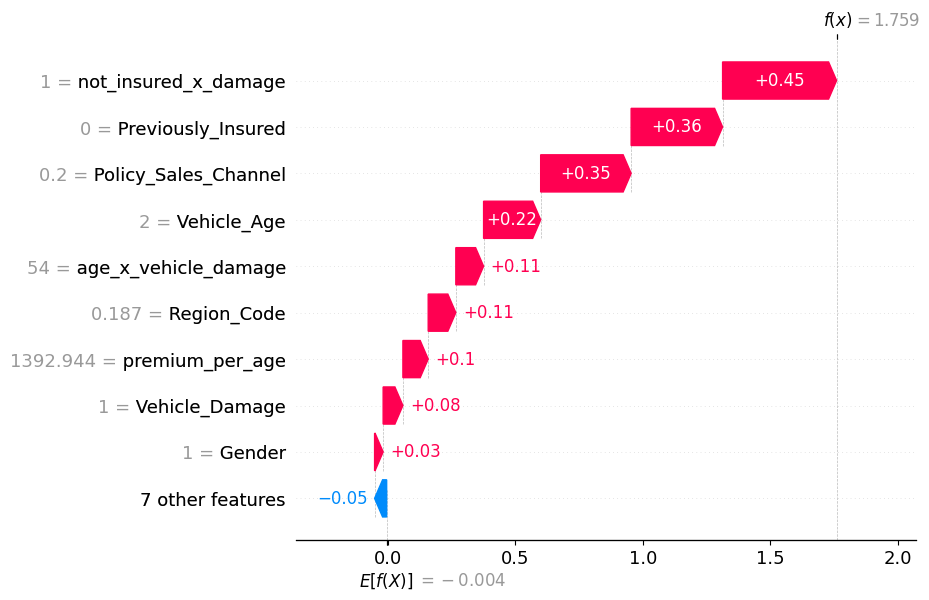


── Predicted non-converter (prob=0.003) ──


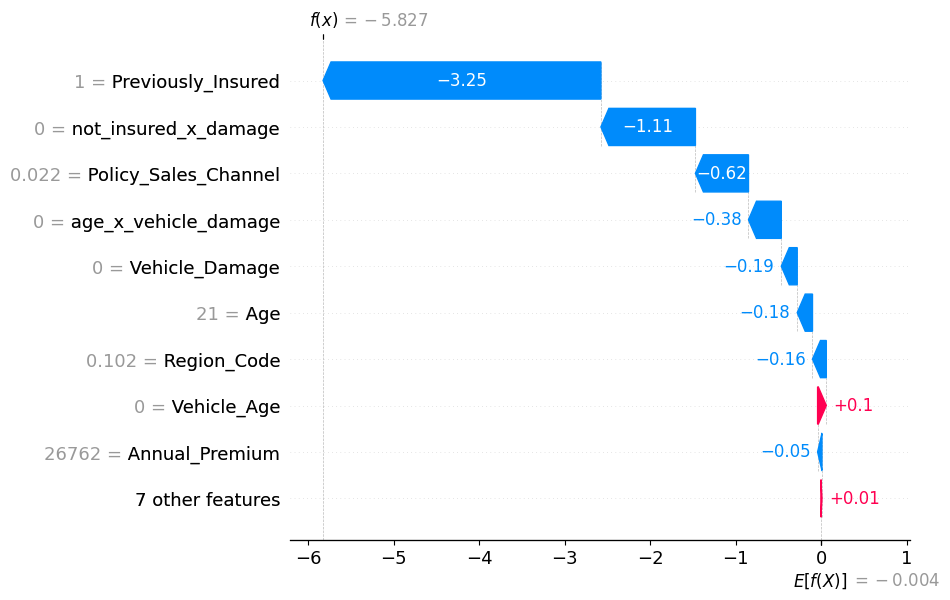

In [5]:
converter_idx     = np.where((y_test.values == 1) & (probs > 0.7))[0][0]
non_converter_idx = np.where((y_test.values == 0) & (probs < 0.1))[0][0]

if isinstance(X_test_transformed, np.ndarray):
    X_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)
else:
    X_transformed_df = X_test_transformed

for label, idx in [("High-probability converter", converter_idx),
                   ("Predicted non-converter",    non_converter_idx)]:
    print(f"\n── {label} (prob={probs[idx]:.3f}) ──")
    shap.waterfall_plot(
        shap.Explanation(
            values        = shap_values[idx],
            base_values   = explainer.expected_value,
            data          = X_transformed_df.iloc[idx].values,
            feature_names = feature_names,
        ),
        show=True,
    )

## 6. SHAP Dependence — Top 2 Features

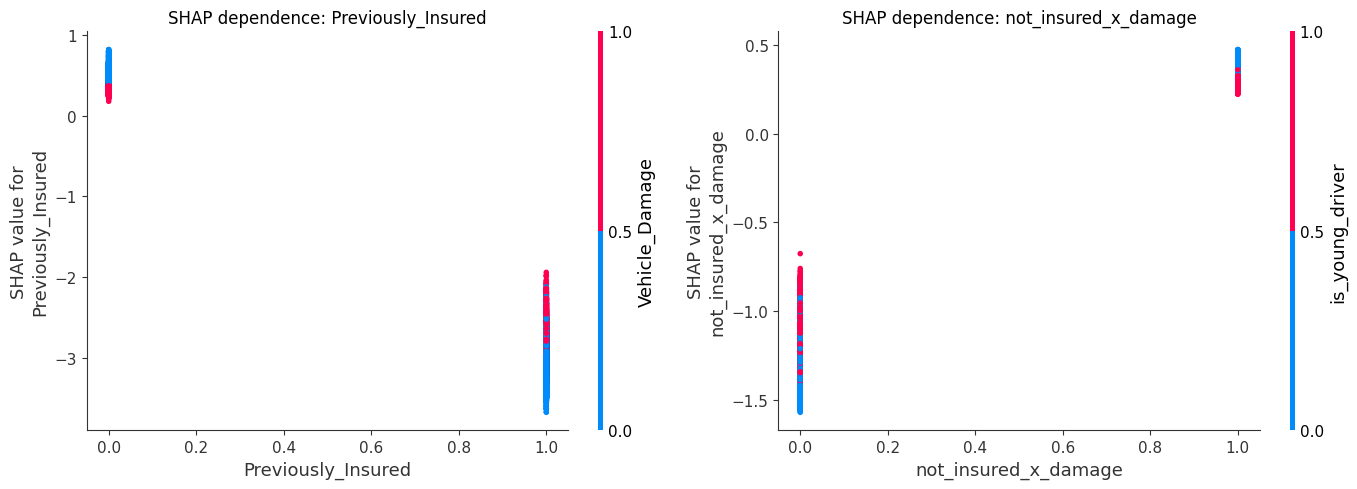

In [6]:
top2 = mean_shap.tail(2).index.tolist()[::-1]

if isinstance(X_test_transformed, np.ndarray):
    X_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)
else:
    X_transformed_df = X_test_transformed

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top2):
    shap.dependence_plot(feat, shap_values, X_transformed_df, ax=ax, show=False)
    ax.set_title(f"SHAP dependence: {feat}")
plt.tight_layout()

## 7. Lift Curve & Decile Analysis

In [7]:
lift_df = (
    pd.DataFrame({"prob": probs, "actual": y_test.values})
    .sort_values("prob", ascending=False)
    .reset_index(drop=True)
)

lift_df["decile"] = pd.qcut(lift_df.index, q=10, labels=range(1, 11))

decile_stats = lift_df.groupby("decile", observed=True).agg(
    n_customers  = ("actual", "count"),
    n_converters = ("actual", "sum"),
    conv_rate    = ("actual", "mean"),
).reset_index()

overall_rate = y_test.mean()
decile_stats["lift"] = decile_stats["conv_rate"] / overall_rate
decile_stats["cum_converters_pct"] = (
    decile_stats["n_converters"].cumsum() / y_test.sum() * 100
)
decile_stats["cum_customers_pct"] = (
    decile_stats["n_customers"].cumsum() / len(y_test) * 100
)

print(decile_stats[["decile","conv_rate","lift","cum_converters_pct"]].to_string(index=False))

decile  conv_rate     lift  cum_converters_pct
     1   0.399318 3.258061           32.584029
     2   0.310286 2.531644           57.899807
     3   0.259512 2.117375           79.073004
     4   0.168197 1.372333           92.795975
     5   0.074390 0.606952           98.865339
     6   0.012333 0.100623           99.871548
     7   0.000787 0.006423           99.935774
     8   0.000262 0.002141           99.957183
     9   0.000262 0.002141           99.978591
    10   0.000262 0.002141          100.000000


## 8. Lift & Cumulative Gain Charts

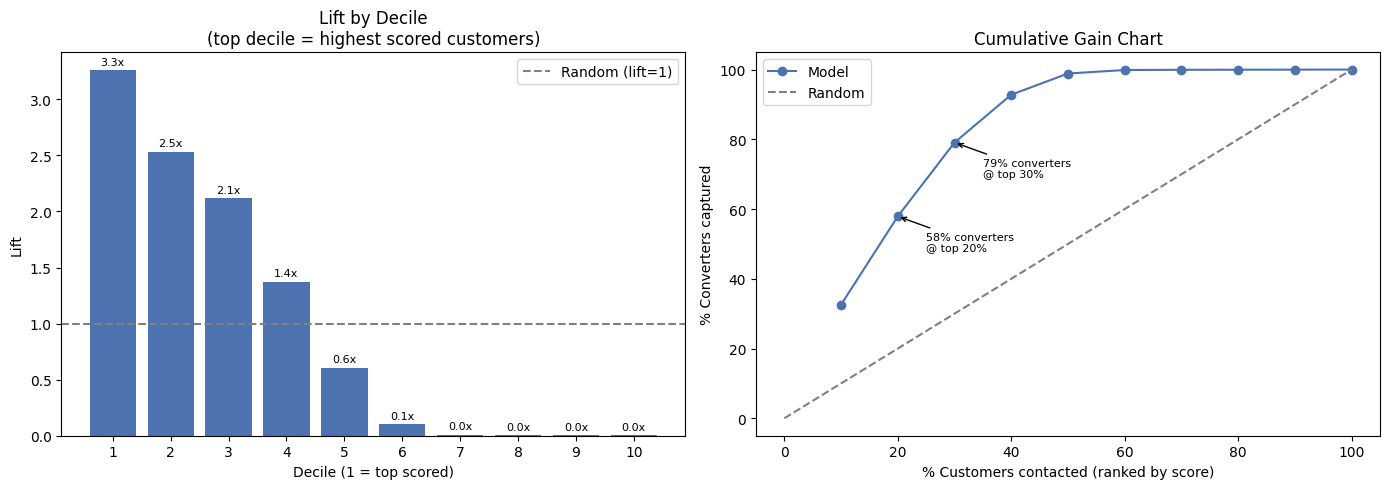

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lift chart
axes[0].bar(decile_stats["decile"].astype(str), decile_stats["lift"], color="#4C72B0")
axes[0].axhline(1.0, color="grey", linestyle="--", label="Random (lift=1)")
axes[0].set_title("Lift by Decile\n(top decile = highest scored customers)")
axes[0].set_xlabel("Decile (1 = top scored)")
axes[0].set_ylabel("Lift")
axes[0].legend()
for i, v in enumerate(decile_stats["lift"]):
    axes[0].text(i, v + 0.05, f"{v:.1f}x", ha="center", fontsize=8)

# Cumulative gain chart
axes[1].plot(
    decile_stats["cum_customers_pct"],
    decile_stats["cum_converters_pct"],
    marker="o", color="#4C72B0", label="Model"
)
axes[1].plot([0, 100], [0, 100], "grey", linestyle="--", label="Random")
axes[1].set_title("Cumulative Gain Chart")
axes[1].set_xlabel("% Customers contacted (ranked by score)")
axes[1].set_ylabel("% Converters captured")
axes[1].legend()

# Annotate 20% and 30% marks
for pct in [20, 30]:
    row = decile_stats[decile_stats["cum_customers_pct"] <= pct + 5].iloc[-1]
    axes[1].annotate(
        f"{row['cum_converters_pct']:.0f}% converters\n@ top {pct}%",
        xy=(row["cum_customers_pct"], row["cum_converters_pct"]),
        xytext=(row["cum_customers_pct"] + 5, row["cum_converters_pct"] - 10),
        arrowprops=dict(arrowstyle="->", color="black"),
        fontsize=8,
    )

plt.tight_layout()

## 9. Business Impact Summary

In [9]:
top1 = decile_stats.iloc[0]
top2 = decile_stats.iloc[1]
top3 = decile_stats.iloc[2]

print("=" * 60)
print("BUSINESS IMPACT SUMMARY")
print("=" * 60)
print(f"Overall conversion rate (baseline):  {overall_rate:.1%}")
print()
print(f"Top 10% of scored customers:")
print(f"  Conversion rate : {top1['conv_rate']:.1%}  ({top1['lift']:.1f}x lift)")
print(f"  Converters captured : {top1['cum_converters_pct']:.0f}% of all converters")
print()
print(f"Top 20% of scored customers:")
print(f"  Conversion rate : {top2['conv_rate']:.1%}  ({top2['lift']:.1f}x lift)")
cum20 = decile_stats.iloc[:2]["n_converters"].sum() / y_test.sum() * 100
print(f"  Converters captured : {cum20:.0f}% of all converters")
print()
print(f"Top 30% of scored customers:")
print(f"  Conversion rate : {top3['conv_rate']:.1%}  ({top3['lift']:.1f}x lift)")
cum30 = decile_stats.iloc[:3]["n_converters"].sum() / y_test.sum() * 100
print(f"  Converters captured : {cum30:.0f}% of all converters")
print()
print("Takeaway: By targeting the top 20% of customers by score, the")
print(f"model captures ~{cum20:.0f}% of all converters while contacting")
print(f"only 20% of the customer base — {cum20/20:.1f}x more efficient than random outreach.")

BUSINESS IMPACT SUMMARY
Overall conversion rate (baseline):  12.3%

Top 10% of scored customers:
  Conversion rate : 39.9%  (3.3x lift)
  Converters captured : 33% of all converters

Top 20% of scored customers:
  Conversion rate : 31.0%  (2.5x lift)
  Converters captured : 58% of all converters

Top 30% of scored customers:
  Conversion rate : 26.0%  (2.1x lift)
  Converters captured : 79% of all converters

Takeaway: By targeting the top 20% of customers by score, the
model captures ~58% of all converters while contacting
only 20% of the customer base — 2.9x more efficient than random outreach.
